# Run SpaDC on spatial ATAC and spatial H3K27ac data of P22

### The data is available at: https://doi.org/10.6084/m9.figshare.30739373

In [1]:
import scanpy as sc
import pandas as pd
import SpaDC 
import torch
import os

# Preparation of data

The mm10.fa.gz reference genome file is not included in this repository due to its large file size. Please download it from the UCSC Genome Browser:

https://hgdownload.soe.ucsc.edu/goldenPath/mm10/bigZips/mm10.fa.gz

After downloading, decompress the file and place mm10.fa under the ./SpaDC/ directory before running the pipeline.

# Importing the data

In [2]:
# Load ATAC and H3K27ac adata
DATA_P22_DIR = "./SpaDC/P22"

ATAC_path = os.path.join(DATA_P22_DIR, "ATAC/adata_peaks_normalized.h5ad")
H3K27ac_path = os.path.join(DATA_P22_DIR, "H3K27ac/adata_peaks_normalized.h5ad")

ATAC = sc.read_h5ad(ATAC_path)
H3K27ac = sc.read_h5ad(H3K27ac_path)

# Merging ATAC and H3K27ac adata

After integrating data, the integrated AnnData object will be saved as integrate.h5ad in the specified save_folder.
In addition, adata1.bed, adata2.bed, overlap.bed, and overlap_seqs.txt will also be generated for overlapping peak identification and sequence extraction.

In [3]:
DATA_DIR = "./SpaDC/integrate/P22"
SpaDC.integrate_data(ATAC, H3K27ac, save_folder=DATA_DIR, fasta_file='./SpaDC/mm10.fa', seq_len=1344)

### If you would like to use the method quickly, you may skip the above Merging step

<h3>Load integrated adata and sequence</h3>

In [4]:
# Load integrated adata and sequence
DATA_DIR = "./SpaDC/integrate/P22"
adata_path = os.path.join(DATA_DIR, "integrate.h5ad")
adata = sc.read_h5ad(adata_path)

seq_path = os.path.join(DATA_DIR, "overlap_seqs.txt")
seq = pd.read_csv(seq_path, sep='\t')

/home/machuanlong/anaconda3/lib/python3.11/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


# Running SpaDC

##### After running SpaDC, the learned spot embeddings with batch correction will be stored in adata.obsm['SpaDC_bc']

##### The embeddings without batch correction will be stored in adata.obsm['SpaDC_raw']

##### The trained model parameters will be saved as model.pt in the current working directory.

In [5]:
adata = SpaDC.train_SpaDC_bc(adata, ATAC, H3K27ac, seq, lambda1=1e-7, lambda2=1e-9, out_dir='', device=torch.device('cuda:8'))

Pretrain with SpaDC...


100%|██████████| 100/100 [1:02:21<00:00, 37.41s/it, train_loss=0.126028]


Train with SpaDC_bc...


100%|██████████| 100/100 [1:37:41<00:00, 58.61s/it, train_loss=0.125179]  


# Clustering on the embeddings

In [6]:
# Cluster spots into 18 categories
adata1 = adata.copy()
sc.pp.neighbors(adata1, use_rep='SpaDC_raw') 
res1, _ = SpaDC.getNClusters(adata1, 18)
sc.tl.leiden(adata1, key_added='SpaDC_raw', resolution=res1)
sc.tl.umap(adata1)

sc.pp.neighbors(adata, use_rep='SpaDC_bc') 
res2, _ = SpaDC.getNClusters(adata, 18)
sc.tl.leiden(adata, key_added='SpaDC_bc', resolution=res2)
sc.tl.umap(adata)

2026-05-09 15:24:58.555377: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 15:24:58.596699: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-09 15:24:58.596725: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-09 15:24:58.598211: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-09 15:24:58.605529: I tensorflow/core/platform/cpu_feature_guar

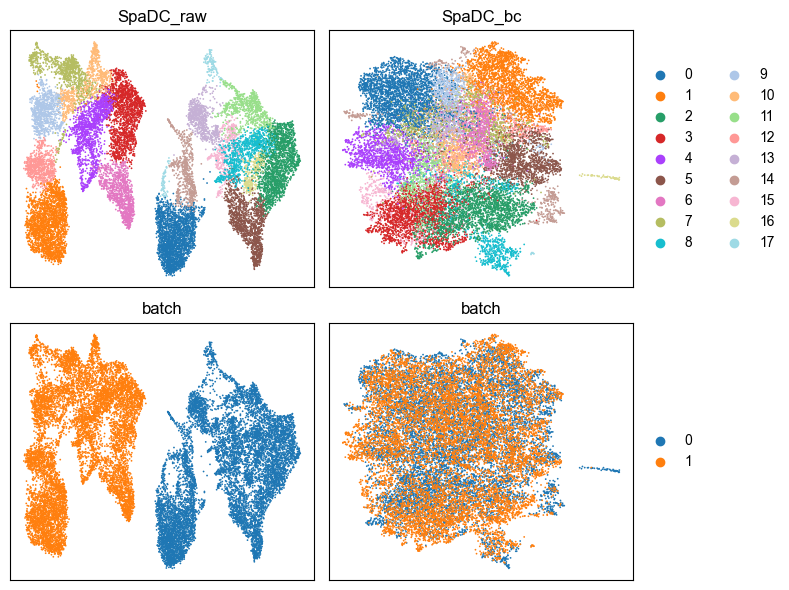

In [7]:
# Visualization
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'

f, ax = plt.subplots(2, 2, figsize=(8, 6))

sc.pl.umap(adata1, color='SpaDC_raw', ax=ax[0, 0], show=False)
sc.pl.umap(adata1, color='batch', ax=ax[1, 0], show=False)

sc.pl.umap(adata, color='SpaDC_bc', ax=ax[0, 1], show=False)
sc.pl.umap(adata, color='batch', ax=ax[1, 1], show=False) 

ax[0, 0].get_legend().remove()
ax[1, 0].get_legend().remove()

ax[0, 0].set_xlabel('')
ax[0, 1].set_xlabel('')
ax[1, 0].set_xlabel('')
ax[1, 1].set_xlabel('')

ax[0, 0].set_ylabel('')
ax[0, 1].set_ylabel('')
ax[1, 0].set_ylabel('')
ax[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

# Spatial Visualization

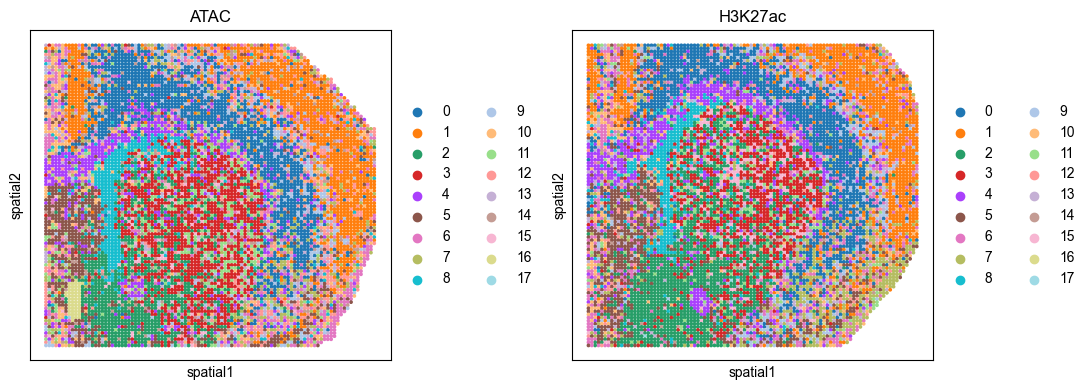

In [8]:
ATAC.obs['ATAC'] = adata.obs['SpaDC_bc'][0:ATAC.n_obs].values
H3K27ac.obs['H3K27ac'] = adata.obs['SpaDC_bc'][ATAC.n_obs:ATAC.n_obs+H3K27ac.n_obs].values

# Rotate spatial coordinates clockwise by 90 degrees
coords = H3K27ac.obsm['spatial'].copy()
H3K27ac.obsm['spatial'][:, 0] = coords[:, 1]
H3K27ac.obsm['spatial'][:, 1] = -coords[:, 0]

f, ax = plt.subplots(1, 2, figsize=(11, 4))

sc.pl.embedding(ATAC, basis='spatial', color='ATAC', size=30, ax=ax[0], show=False)
sc.pl.embedding(H3K27ac, basis='spatial', color='H3K27ac', size=30, ax=ax[1], show=False)

plt.tight_layout()
plt.show()